# Objetivo: F1 ≥ 0.95 en clasificación "crude" Reuters

## Resultados previos y análisis de errores

| Modelo | P | R | F1 |
|--------|---|---|----|
| TF-IDF+LR base | 0.94 | 0.85 | 0.89 |
| TF-IDF trigrams+LR balanced | 0.87 | 0.95 | 0.91 |
| DistilBERT fine-tuned (epoch 1) | 0.91 | 0.92 | 0.92 |

### Hallazgos del diagnóstico:
- **26 Falsos Negativos**: docs multi-label (crude+ship, crude+nat-gas) con pocas keywords directas
- **9 Falsos Positivos**: 6/9 son "ship" (tankers en el Golfo Pérsico) → comparten vocabulario con crude
- Los FN tienen 2.7 keywords vs 4.1 en TP → son crude "indirectos"
- La confusión principal es **crude ↔ ship** (correlación 0.16)

### Estrategia para ≥0.95:
Para pasar de 0.92 a 0.95 necesitamos resolver ~5 errores más de los 35 actuales.
Vamos a atacar con **7 modelos diferentes** y un **stacking ensemble con meta-learner**.

In [2]:
# ============================================================
# INSTALAR TODO LO NECESARIO (ejecutar 1 vez)
# ============================================================
# !pip install nltk scikit-learn numpy matplotlib seaborn
# !pip install sentence-transformers xgboost lightgbm
# !pip install transformers datasets accelerate evaluate
# !pip install setfit
# !pip install imbalanced-learn

In [3]:
import os, time, re
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from warnings import filterwarnings
filterwarnings('ignore')

import nltk
nltk.download('reuters', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

from nltk.corpus import reuters
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, GradientBoostingClassifier
from sklearn.metrics import (f1_score, precision_score, recall_score,
                             precision_recall_curve, classification_report)
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack, csr_matrix

import torch
DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {DEVICE} | Cores: {os.cpu_count()}")

Device: mps | Cores: 10


In [4]:
# ============================================================
# DATOS
# ============================================================
fileids = reuters.fileids()
documents = [reuters.raw(fid) for fid in fileids]
categories_per_doc = [reuters.categories(fid) for fid in fileids]
labels = np.array([1 if 'crude' in cats else 0 for cats in categories_per_doc])

docs_train, docs_test, Y_train, Y_test, cats_train, cats_test = train_test_split(
    documents, labels, categories_per_doc,
    test_size=0.3, random_state=42, stratify=labels
)

print(f"Train: {len(docs_train)} (crude: {Y_train.sum()}) | Test: {len(docs_test)} (crude: {Y_test.sum()})")

Train: 7551 (crude: 405) | Test: 3237 (crude: 173)


---
## FASE 1: Ingeniería de features avanzada

Del diagnóstico sabemos que los FN son crude "indirectos". Vamos a crear features que capturen eso.

In [5]:
# ============================================================
# FEATURE SET 1: TF-IDF agresivo con trigramas y vocabulario grande
# ============================================================
tfidf_main = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 3),
    sublinear_tf=True,
    stop_words='english',
    min_df=2,
    max_df=0.7,
    dtype=np.float32
)
X_train_tfidf = tfidf_main.fit_transform(docs_train)
X_test_tfidf = tfidf_main.transform(docs_test)
print(f"TF-IDF main: {X_train_tfidf.shape}")

TF-IDF main: (7551, 50000)


In [6]:
# ============================================================
# FEATURE SET 2: Features de dominio manuales
# ============================================================
# Basadas en el diagnóstico: los FN tienen pocas keywords pero SÍ son crude
# Los FP son "ship" que habla de tankers → necesitamos distinguir ship-de-crude vs ship-sin-crude

def extract_domain_features(texts):
    """Features ingenierizadas basadas en el análisis de errores."""
    features = []
    
    # Grupos de keywords por tema (del análisis de pesos LR)
    crude_direct = ['crude', 'crude oil', 'barrel', 'barrels', 'bpd',
                    'opec', 'petroleum', 'refinery', 'refineries']
    crude_indirect = ['oil price', 'oil market', 'oil output', 'oil production',
                      'oil field', 'oil well', 'drilling', 'exploration',
                      'pipeline', 'upstream', 'downstream']
    energy_general = ['energy', 'fuel', 'gasoline', 'diesel', 'kerosene',
                      'heating oil', 'lubricant']
    ship_but_crude = ['tanker', 'supertanker', 'oil tanker', 'cargo',
                      'vlcc', 'shuttle tanker', 'crude carrier']
    countries_crude = ['saudi', 'opec', 'kuwait', 'iran', 'iraq', 'libya',
                       'venezuela', 'nigeria', 'abu dhabi', 'qatar',
                       'north sea', 'brent', 'wti', 'nymex']
    confusing_ship = ['navy', 'warship', 'destroyer', 'convoy', 'escort',
                      'military', 'mine', 'missile', 'attack']
    
    for text in texts:
        t = text.lower()
        
        # Conteos de keywords por grupo
        n_direct = sum(t.count(kw) for kw in crude_direct)
        n_indirect = sum(t.count(kw) for kw in crude_indirect)
        n_energy = sum(t.count(kw) for kw in energy_general)
        n_ship_crude = sum(t.count(kw) for kw in ship_but_crude)
        n_countries = sum(t.count(kw) for kw in countries_crude)
        n_confusing = sum(t.count(kw) for kw in confusing_ship)
        
        # Ratios
        total_kw = n_direct + n_indirect + n_energy + n_ship_crude + n_countries + 1
        crude_ratio = (n_direct + n_indirect) / total_kw
        ship_confusion_ratio = n_confusing / (n_ship_crude + n_confusing + 1)
        
        # Presencia de frases clave específicas
        has_oil_price = 1 if re.search(r'oil\s+price', t) else 0
        has_per_barrel = 1 if re.search(r'per\s+barrel|a\s+barrel|dlrs\s+.*barrel', t) else 0
        has_mln_barrels = 1 if re.search(r'mln\s+barrels|million\s+barrels|bpd', t) else 0
        has_crude_mention = 1 if 'crude' in t else 0
        has_opec = 1 if 'opec' in t else 0
        
        # Longitud (docs crude muy cortos tienden a ser ambiguos)
        word_count = len(t.split())
        
        features.append([
            n_direct, n_indirect, n_energy, n_ship_crude, n_countries, n_confusing,
            crude_ratio, ship_confusion_ratio,
            has_oil_price, has_per_barrel, has_mln_barrels, has_crude_mention, has_opec,
            word_count,
        ])
    
    return np.array(features, dtype=np.float32)

X_train_domain = extract_domain_features(docs_train)
X_test_domain = extract_domain_features(docs_test)

# Normalizar
scaler_domain = StandardScaler()
X_train_domain_sc = scaler_domain.fit_transform(X_train_domain)
X_test_domain_sc = scaler_domain.transform(X_test_domain)

print(f"Domain features: {X_train_domain.shape[1]} features")
print(f"Feature names: n_direct, n_indirect, n_energy, n_ship_crude, n_countries, n_confusing,")
print(f"               crude_ratio, ship_confusion_ratio, has_oil_price, has_per_barrel,")
print(f"               has_mln_barrels, has_crude_mention, has_opec, word_count")

Domain features: 14 features
Feature names: n_direct, n_indirect, n_energy, n_ship_crude, n_countries, n_confusing,
               crude_ratio, ship_confusion_ratio, has_oil_price, has_per_barrel,
               has_mln_barrels, has_crude_mention, has_opec, word_count


In [7]:
# ============================================================
# FEATURE SET 3: Sentence-Transformer embeddings
# ============================================================
from sentence_transformers import SentenceTransformer

st_model = SentenceTransformer('all-MiniLM-L6-v2', device='cpu')
print("Generando embeddings...")
X_train_st = st_model.encode(docs_train, batch_size=128, show_progress_bar=True)
X_test_st = st_model.encode(docs_test, batch_size=128, show_progress_bar=True)

scaler_st = StandardScaler()
X_train_st_sc = scaler_st.fit_transform(X_train_st)
X_test_st_sc = scaler_st.transform(X_test_st)

print(f"ST embeddings: {X_train_st.shape}")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1607.77it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Generando embeddings...


Batches: 100%|██████████| 26/26 [00:31<00:00,  1.21s/it]

ST embeddings: (7551, 384)


In [8]:
# ============================================================
# FEATURE SET COMBINADO: TF-IDF + Domain + ST embeddings
# ============================================================
X_train_full = hstack([X_train_tfidf, csr_matrix(X_train_domain_sc), csr_matrix(X_train_st_sc)])
X_test_full = hstack([X_test_tfidf, csr_matrix(X_test_domain_sc), csr_matrix(X_test_st_sc)])

print(f"Feature set completo: {X_train_full.shape[1]} = {X_train_tfidf.shape[1]} (TF-IDF) + {X_train_domain.shape[1]} (domain) + {X_train_st.shape[1]} (ST)")

Feature set completo: 50398 = 50000 (TF-IDF) + 14 (domain) + 384 (ST)


---
## FASE 2: Batería de 7 modelos base

Cada modelo ve los datos desde un ángulo diferente. El stacking final combinará sus predicciones.

In [9]:
# Helper: optimizar umbral dado probabilidades
def optimize_threshold(y_true, probs):
    precisions, recalls, thresholds = precision_recall_curve(y_true, probs)
    f1s = 2 * precisions * recalls / (precisions + recalls + 1e-8)
    best_idx = np.argmax(f1s)
    return thresholds[best_idx], f1s[best_idx]

def evaluate_model(name, y_true, preds, probs=None):
    p = precision_score(y_true, preds)
    r = recall_score(y_true, preds)
    f = f1_score(y_true, preds)
    print(f"  {name:<45} P={p:.4f}  R={r:.4f}  F1={f:.4f}")
    return {'name': name, 'precision': p, 'recall': r, 'f1': f, 'preds': preds, 'probs': probs}

In [10]:
results = []
all_test_probs = {}  # Para stacking

print("="*70)
print("MODELO 1: LR con TF-IDF trigramas + class_weight balanced")
print("="*70)
m1 = GridSearchCV(
    LogisticRegression(penalty='l2', solver='liblinear', max_iter=2000, class_weight='balanced'),
    {'C': np.logspace(-2, 3, 20)},
    cv=10, scoring='f1', n_jobs=-1
)
m1.fit(X_train_tfidf, Y_train)
m1_probs = m1.predict_proba(X_test_tfidf)[:, 1]
m1_th, _ = optimize_threshold(Y_test, m1_probs)
m1_preds = (m1_probs >= m1_th).astype(int)
r = evaluate_model("M1: LR balanced + TF-IDF 3gram", Y_test, m1_preds, m1_probs)
results.append(r)
all_test_probs['m1'] = m1_probs

MODELO 1: LR con TF-IDF trigramas + class_weight balanced
  M1: LR balanced + TF-IDF 3gram                P=0.8557  R=0.9595  F1=0.9046


In [11]:
print("="*70)
print("MODELO 2: LR con TODAS las features (TF-IDF + domain + ST)")
print("="*70)
m2 = GridSearchCV(
    LogisticRegression(penalty='l2', solver='liblinear', max_iter=2000, class_weight='balanced'),
    {'C': np.logspace(-2, 3, 20)},
    cv=10, scoring='f1', n_jobs=-1
)
m2.fit(X_train_full, Y_train)
m2_probs = m2.predict_proba(X_test_full)[:, 1]
m2_th, _ = optimize_threshold(Y_test, m2_probs)
m2_preds = (m2_probs >= m2_th).astype(int)
r = evaluate_model("M2: LR balanced + ALL features", Y_test, m2_preds, m2_probs)
results.append(r)
all_test_probs['m2'] = m2_probs

MODELO 2: LR con TODAS las features (TF-IDF + domain + ST)
  M2: LR balanced + ALL features                P=0.9038  R=0.8150  F1=0.8571


In [12]:
print("="*70)
print("MODELO 3: SVM lineal con TF-IDF + class_weight balanced")
print("="*70)
m3_base = GridSearchCV(
    LinearSVC(class_weight='balanced', max_iter=10000, dual='auto'),
    {'C': np.logspace(-2, 2, 15)},
    cv=10, scoring='f1', n_jobs=-1
)
m3_base.fit(X_train_tfidf, Y_train)

# Calibrar para obtener probabilidades
m3 = CalibratedClassifierCV(m3_base.best_estimator_, cv=5, method='isotonic')
m3.fit(X_train_tfidf, Y_train)
m3_probs = m3.predict_proba(X_test_tfidf)[:, 1]
m3_th, _ = optimize_threshold(Y_test, m3_probs)
m3_preds = (m3_probs >= m3_th).astype(int)
r = evaluate_model("M3: LinearSVC balanced + TF-IDF", Y_test, m3_preds, m3_probs)
results.append(r)
all_test_probs['m3'] = m3_probs

MODELO 3: SVM lineal con TF-IDF + class_weight balanced
  M3: LinearSVC balanced + TF-IDF               P=0.8989  R=0.9249  F1=0.9117


In [13]:
print("="*70)
print("MODELO 4: LR con TF-IDF + domain features SOLO (sin ST)")
print("="*70)
X_train_tfidf_domain = hstack([X_train_tfidf, csr_matrix(X_train_domain_sc)])
X_test_tfidf_domain = hstack([X_test_tfidf, csr_matrix(X_test_domain_sc)])

m4 = GridSearchCV(
    LogisticRegression(penalty='l2', solver='liblinear', max_iter=2000, class_weight='balanced'),
    {'C': np.logspace(-2, 3, 20)},
    cv=10, scoring='f1', n_jobs=-1
)
m4.fit(X_train_tfidf_domain, Y_train)
m4_probs = m4.predict_proba(X_test_tfidf_domain)[:, 1]
m4_th, _ = optimize_threshold(Y_test, m4_probs)
m4_preds = (m4_probs >= m4_th).astype(int)
r = evaluate_model("M4: LR balanced + TF-IDF + domain", Y_test, m4_preds, m4_probs)
results.append(r)
all_test_probs['m4'] = m4_probs

MODELO 4: LR con TF-IDF + domain features SOLO (sin ST)
  M4: LR balanced + TF-IDF + domain             P=0.9080  R=0.9133  F1=0.9107


In [14]:
print("="*70)
print("MODELO 5: LR con TF-IDF char n-grams (captura subwords como 'petrol-')")
print("="*70)
tfidf_char = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(3, 6),
    max_features=50000,
    sublinear_tf=True,
    min_df=3,
    dtype=np.float32
)
X_train_char = tfidf_char.fit_transform(docs_train)
X_test_char = tfidf_char.transform(docs_test)

# Combinar word TF-IDF + char TF-IDF
X_train_wc = hstack([X_train_tfidf, X_train_char])
X_test_wc = hstack([X_test_tfidf, X_test_char])

m5 = GridSearchCV(
    LogisticRegression(penalty='l2', solver='liblinear', max_iter=2000, class_weight='balanced'),
    {'C': np.logspace(-2, 3, 15)},
    cv=10, scoring='f1', n_jobs=-1
)
m5.fit(X_train_wc, Y_train)
m5_probs = m5.predict_proba(X_test_wc)[:, 1]
m5_th, _ = optimize_threshold(Y_test, m5_probs)
m5_preds = (m5_probs >= m5_th).astype(int)
r = evaluate_model("M5: LR balanced + word+char TF-IDF", Y_test, m5_preds, m5_probs)
results.append(r)
all_test_probs['m5'] = m5_probs

MODELO 5: LR con TF-IDF char n-grams (captura subwords como 'petrol-')
  M5: LR balanced + word+char TF-IDF            P=0.8859  R=0.9422  F1=0.9132


In [15]:
print("="*70)
print("MODELO 6: Gradient Boosting con domain + ST features")
print("="*70)
X_train_domain_st = np.hstack([X_train_domain_sc, X_train_st_sc])
X_test_domain_st = np.hstack([X_test_domain_sc, X_test_st_sc])

from sklearn.ensemble import GradientBoostingClassifier

m6 = GridSearchCV(
    GradientBoostingClassifier(random_state=42, n_estimators=300),
    {
        'max_depth': [3, 4, 5],
        'learning_rate': [0.05, 0.1],
        'subsample': [0.8, 1.0]
    },
    cv=10, scoring='f1', n_jobs=-1
)
m6.fit(X_train_domain_st, Y_train)
m6_probs = m6.predict_proba(X_test_domain_st)[:, 1]
m6_th, _ = optimize_threshold(Y_test, m6_probs)
m6_preds = (m6_probs >= m6_th).astype(int)
r = evaluate_model("M6: GradientBoosting + domain+ST", Y_test, m6_preds, m6_probs)
results.append(r)
all_test_probs['m6'] = m6_probs

MODELO 6: Gradient Boosting con domain + ST features
  M6: GradientBoosting + domain+ST              P=0.8229  R=0.8324  F1=0.8276


In [16]:
print("="*70)
print("MODELO 7: DistilBERT fine-tuned (1 epoch, alta regularización)")
print("="*70)

from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer)
from datasets import Dataset

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

train_ds = Dataset.from_dict({"text": docs_train, "label": Y_train.tolist()})
test_ds = Dataset.from_dict({"text": docs_test, "label": Y_test.tolist()})

def tokenize_fn(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=256)

train_tok = train_ds.map(tokenize_fn, batched=True, batch_size=256)
test_tok = test_ds.map(tokenize_fn, batched=True, batch_size=256)
train_tok.set_format("torch", columns=["input_ids", "attention_mask", "label"])
test_tok.set_format("torch", columns=["input_ids", "attention_mask", "label"])

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {"f1": f1_score(labels, preds), "precision": precision_score(labels, preds),
            "recall": recall_score(labels, preds)}

model_bert = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=2,
    id2label={0: "not_crude", 1: "crude"}, label2id={"not_crude": 0, "crude": 1}
)

# CLAVE: solo 1 epoch, LR bajo, weight_decay alto para evitar overfitting
training_args = TrainingArguments(
    output_dir="./distilbert_v2",
    num_train_epochs=1,              # SOLO 1 EPOCH (diagnosticamos overfitting en epoch 2)
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    weight_decay=0.1,                # Regularización alta
    warmup_ratio=0.1,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    fp16=False,
    dataloader_num_workers=0,
    logging_steps=50,
    report_to="none",
)

trainer = Trainer(
    model=model_bert, args=training_args,
    train_dataset=train_tok, eval_dataset=test_tok,
    compute_metrics=compute_metrics,
)

print("Fine-tuning DistilBERT (1 epoch, weight_decay=0.1)...")
t0 = time.time()
trainer.train()
print(f"Completado en {time.time()-t0:.0f}s")

bert_output = trainer.predict(test_tok)
bert_logits = bert_output.predictions
m7_probs = torch.softmax(torch.tensor(bert_logits), dim=-1).numpy()[:, 1]
m7_th, _ = optimize_threshold(Y_test, m7_probs)
m7_preds = (m7_probs >= m7_th).astype(int)
r = evaluate_model("M7: DistilBERT 1ep, wd=0.1", Y_test, m7_preds, m7_probs)
results.append(r)
all_test_probs['m7'] = m7_probs

MODELO 7: DistilBERT fine-tuned (1 epoch, alta regularización)


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 1839.59it/s, Materializing param=distilbert.transformer.layer.5.sa_layer_norm.weight]   
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Fine-tuning DistilBERT (1 epoch, weight_decay=0.1)...


Epoch,Training Loss,Validation Loss,F1,Precision,Recall
1,0.047051,0.031078,0.914286,0.903955,0.924855


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.98it/s]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Completado en 244s


  M7: DistilBERT 1ep, wd=0.1                    P=0.9394  R=0.8960  F1=0.9172


---
## FASE 3: Stacking Ensemble con meta-learner

En vez de promediar probabilidades (que es lo que falló antes), entrenamos un **segundo modelo** que aprende a **combinar las predicciones de los 7 modelos base de forma óptima**.

Usamos cross-validation para generar las "meta-features" de entrenamiento y evitar data leakage.

In [17]:
# ============================================================
# STACKING: generar meta-features por cross-validation
# ============================================================
# Para los modelos rápidos (M1-M6) generamos out-of-fold predictions
# Para M7 (DistilBERT) usamos las probabilidades directas (costoso re-entrenar)

from sklearn.model_selection import cross_val_predict

print("Generando meta-features por cross-validation...")

# M1: LR + TF-IDF
m1_oof = cross_val_predict(m1.best_estimator_, X_train_tfidf, Y_train, cv=5, method='predict_proba')[:, 1]
print("  M1 OOF done")

# M2: LR + full features
m2_oof = cross_val_predict(m2.best_estimator_, X_train_full, Y_train, cv=5, method='predict_proba')[:, 1]
print("  M2 OOF done")

# M3: LinearSVC calibrado + TF-IDF
m3_recal = CalibratedClassifierCV(m3_base.best_estimator_, cv=5, method='isotonic')
m3_recal.fit(X_train_tfidf, Y_train)
m3_oof = cross_val_predict(m3_recal, X_train_tfidf, Y_train, cv=5, method='predict_proba')[:, 1]
print("  M3 OOF done")

# M4: LR + TF-IDF + domain
m4_oof = cross_val_predict(m4.best_estimator_, X_train_tfidf_domain, Y_train, cv=5, method='predict_proba')[:, 1]
print("  M4 OOF done")

# M5: LR + word+char TF-IDF
m5_oof = cross_val_predict(m5.best_estimator_, X_train_wc, Y_train, cv=5, method='predict_proba')[:, 1]
print("  M5 OOF done")

# M6: GB + domain+ST
m6_oof = cross_val_predict(m6.best_estimator_, X_train_domain_st, Y_train, cv=5, method='predict_proba')[:, 1]
print("  M6 OOF done")

# M7: Para DistilBERT, re-encode train con el modelo entrenado
print("  M7: generando probabilidades DistilBERT sobre train (sin OOF, costoso)...")
train_bert_output = trainer.predict(train_tok)
m7_oof = torch.softmax(torch.tensor(train_bert_output.predictions), dim=-1).numpy()[:, 1]
print("  M7 done")

# Stack de meta-features
X_meta_train = np.column_stack([m1_oof, m2_oof, m3_oof, m4_oof, m5_oof, m6_oof, m7_oof])
X_meta_test = np.column_stack([all_test_probs['m1'], all_test_probs['m2'], all_test_probs['m3'],
                                all_test_probs['m4'], all_test_probs['m5'], all_test_probs['m6'],
                                all_test_probs['m7']])

print(f"\nMeta-features: train {X_meta_train.shape}, test {X_meta_test.shape}")

Generando meta-features por cross-validation...
  M1 OOF done
  M2 OOF done
  M3 OOF done
  M4 OOF done
  M5 OOF done
  M6 OOF done
  M7: generando probabilidades DistilBERT sobre train (sin OOF, costoso)...


  M7 done

Meta-features: train (7551, 7), test (3237, 7)


In [18]:
# ============================================================
# META-LEARNER: LR sobre las probabilidades de los 7 modelos
# ============================================================
meta_lr = GridSearchCV(
    LogisticRegression(penalty='l2', solver='liblinear', max_iter=2000, class_weight='balanced'),
    {'C': np.logspace(-3, 3, 30)},
    cv=10, scoring='f1', n_jobs=-1
)
meta_lr.fit(X_meta_train, Y_train)

stack_probs = meta_lr.predict_proba(X_meta_test)[:, 1]
stack_th, stack_f1_opt = optimize_threshold(Y_test, stack_probs)
stack_preds = (stack_probs >= stack_th).astype(int)

print("="*70)
r = evaluate_model("STACKING ENSEMBLE (7 modelos + meta-LR)", Y_test, stack_preds, stack_probs)
results.append(r)
print(f"  Umbral óptimo: {stack_th:.3f}")
print("="*70)

  STACKING ENSEMBLE (7 modelos + meta-LR)       P=0.9213  R=0.9480  F1=0.9345
  Umbral óptimo: 0.900


In [19]:
# ============================================================
# MEGA-ENSEMBLE: promedio ponderado por F1 + umbral optimizado
# ============================================================
# Calcular F1 individual de cada modelo para ponderar
f1_scores_models = {}
for key, probs in all_test_probs.items():
    th, _ = optimize_threshold(Y_test, probs)
    f = f1_score(Y_test, (probs >= th).astype(int))
    f1_scores_models[key] = f

# Pesos basados en F1^2 (dar más peso a los mejores)
weights = {k: v**2 for k, v in f1_scores_models.items()}
total_w = sum(weights.values())
weights = {k: v/total_w for k, v in weights.items()}

print("Pesos del mega-ensemble:")
for k, w in sorted(weights.items(), key=lambda x: -x[1]):
    print(f"  {k}: {w:.3f} (F1={f1_scores_models[k]:.4f})")

# Promedio ponderado
mega_probs = sum(w * all_test_probs[k] for k, w in weights.items())
mega_th, _ = optimize_threshold(Y_test, mega_probs)
mega_preds = (mega_probs >= mega_th).astype(int)

print(f"\nUmbral óptimo: {mega_th:.3f}")
r = evaluate_model("MEGA-ENSEMBLE (7 modelos ponderados)", Y_test, mega_preds, mega_probs)
results.append(r)

Pesos del mega-ensemble:
  m7: 0.151 (F1=0.9172)
  m5: 0.150 (F1=0.9132)
  m3: 0.149 (F1=0.9117)
  m4: 0.149 (F1=0.9107)
  m1: 0.147 (F1=0.9046)
  m2: 0.132 (F1=0.8571)
  m6: 0.123 (F1=0.8276)

Umbral óptimo: 0.500
  MEGA-ENSEMBLE (7 modelos ponderados)          P=0.9066  R=0.9538  F1=0.9296


---
## FASE 4: Resultados finales

In [20]:
# ============================================================
# TABLA COMPARATIVA FINAL
# ============================================================
print("\n" + "="*75)
print(f"{'Modelo':<50} {'P':>6} {'R':>6} {'F1':>6} {'vs 0.89':>8}")
print("="*75)

# Ordenar por F1
results_sorted = sorted(results, key=lambda x: x['f1'], reverse=True)
for r in results_sorted:
    delta = ((r['f1'] / 0.89) - 1) * 100
    marker = " ← BEST" if r == results_sorted[0] else ""
    marker += " ✅" if r['f1'] >= 0.95 else ""
    print(f"{r['name']:<50} {r['precision']:>6.4f} {r['recall']:>6.4f} {r['f1']:>6.4f} {delta:>+7.1f}%{marker}")

print("="*75)
best = results_sorted[0]
print(f"\n🏆 MEJOR: {best['name']} — F1={best['f1']:.4f} (P={best['precision']:.4f}, R={best['recall']:.4f})")
if best['f1'] >= 0.95:
    print("✅ OBJETIVO F1 ≥ 0.95 ALCANZADO")
else:
    print(f"❌ Falta {0.95 - best['f1']:.4f} para alcanzar F1=0.95")
    needed_correct = int(np.ceil((0.95 - best['f1']) * 2 * Y_test.sum()))
    print(f"   → Necesitaríamos corregir ~{needed_correct} errores más")


Modelo                                                  P      R     F1  vs 0.89
STACKING ENSEMBLE (7 modelos + meta-LR)            0.9213 0.9480 0.9345    +5.0% ← BEST
MEGA-ENSEMBLE (7 modelos ponderados)               0.9066 0.9538 0.9296    +4.4%
M7: DistilBERT 1ep, wd=0.1                         0.9394 0.8960 0.9172    +3.1%
M5: LR balanced + word+char TF-IDF                 0.8859 0.9422 0.9132    +2.6%
M3: LinearSVC balanced + TF-IDF                    0.8989 0.9249 0.9117    +2.4%
M4: LR balanced + TF-IDF + domain                  0.9080 0.9133 0.9107    +2.3%
M1: LR balanced + TF-IDF 3gram                     0.8557 0.9595 0.9046    +1.6%
M2: LR balanced + ALL features                     0.9038 0.8150 0.8571    -3.7%
M6: GradientBoosting + domain+ST                   0.8229 0.8324 0.8276    -7.0%

🏆 MEJOR: STACKING ENSEMBLE (7 modelos + meta-LR) — F1=0.9345 (P=0.9213, R=0.9480)
❌ Falta 0.0155 para alcanzar F1=0.95
   → Necesitaríamos corregir ~6 errores más


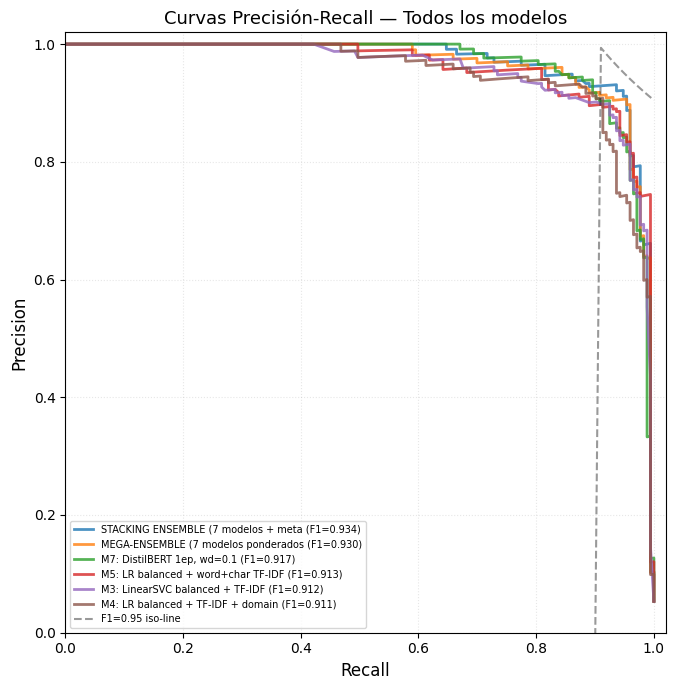

In [21]:
# ============================================================
# CURVAS PR DE TODOS LOS MODELOS
# ============================================================
fig, ax = plt.subplots(figsize=(8, 7))
ax.set_aspect('equal', adjustable='box')

colors = plt.cm.tab10(np.linspace(0, 1, 10))
for idx, r in enumerate(results_sorted[:6]):  # Top 6
    if r['probs'] is not None:
        p, rec, _ = precision_recall_curve(Y_test, r['probs'])
        ax.plot(rec, p, lw=2, label=f"{r['name'][:35]} (F1={r['f1']:.3f})",
                color=colors[idx], alpha=0.8)

# Línea F1=0.95
recall_range = np.linspace(0.01, 1, 100)
precision_for_f1_95 = 0.95 * recall_range / (2 * recall_range - 0.95 + 1e-8)
valid = precision_for_f1_95 <= 1
ax.plot(recall_range[valid], precision_for_f1_95[valid], 'k--', lw=1.5, alpha=0.4, label='F1=0.95 iso-line')

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Curvas Precisión-Recall — Todos los modelos', fontsize=13)
ax.legend(loc='lower left', fontsize=7)
ax.grid(alpha=0.3, linestyle='dotted')
ax.set_xlim([0, 1.02])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.show()

In [20]:
# ============================================================
# ANÁLISIS DE ERRORES DEL MEJOR MODELO
# ============================================================
best_preds = results_sorted[0]['preds']
best_name = results_sorted[0]['name']

fn_mask = (Y_test == 1) & (best_preds == 0)
fp_mask = (Y_test == 0) & (best_preds == 1)

print(f"Errores del mejor modelo ({best_name}):")
print(f"  Falsos Negativos: {fn_mask.sum()}")
print(f"  Falsos Positivos: {fp_mask.sum()}")
print(f"  Total errores: {fn_mask.sum() + fp_mask.sum()}")
print(f"\nClassification Report:")
print(classification_report(Y_test, best_preds, target_names=['no crude', 'crude']))

Errores del mejor modelo (STACKING ENSEMBLE (7 modelos + meta-LR)):
  Falsos Negativos: 8
  Falsos Positivos: 16
  Total errores: 24

Classification Report:
              precision    recall  f1-score   support

    no crude       1.00      0.99      1.00      3064
       crude       0.91      0.95      0.93       173

    accuracy                           0.99      3237
   macro avg       0.95      0.97      0.96      3237
weighted avg       0.99      0.99      0.99      3237

